In [8]:
from graphviz import Digraph
from torch import nn
import math

In [2]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(
        format="svg",
        graph_attr={"rankdir": "LR"}
    )

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
            shape="record"
        )

        if n._op:
            dot.node(
                name=uid + n._op,
                label=n._op
            )

            dot.edge(
                uid + n._op,
                uid
            )

    for n1, n2 in edges:
        dot.edge(
            str(id(n1)),
            str(id(n2)) + n2._op
        )

    return dot

建立一个Value类

In [20]:
class Value:
    def __init__(self,data,_children=(),_op="",label=''):
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self.grad=0.0
        self.label=label
        self._backward=lambda:None
    
    def __repr__(self):
        return f'Value={self.data}'

    def __add__(self,other):
        out=Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad+=1.00*out.grad
            other.grad+=1.00*out.grad
        out._backward=_backward
        return out

    def __mul__(self,other):
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data *out.grad
            other.grad+=self.data *out.grad
        out._backward=_backward
        return out
    def tanh(self):
        t=math.tanh(self.data)
        out=Value(t,(self,),'tanh')
        def _backward():
            self.grad+=(1-t**2)*out.grad

        out._backward=_backward
        return out

    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0

        for node in reversed(topo):
            node._backward()


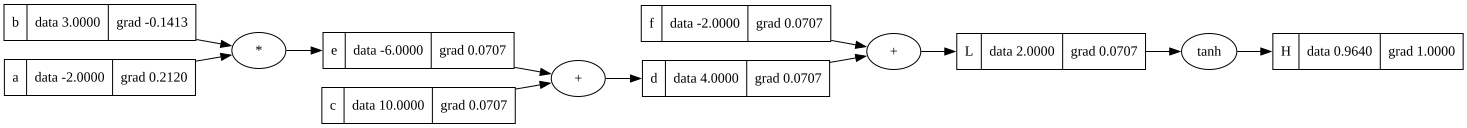

In [21]:
a=Value(-2.0,label='a')
b=Value(3.0,label='b')
c=Value(10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f');f.label='f'
L=d+f;L.label='L'
H=L.tanh();H.label='H'
H.backward()   
draw_dot(H)